In [1]:
!pip install numpy pandas matplotlib seaborn 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('economic_index.csv')
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [10]:
# Removing unnecessary columns
df.drop(columns = ["Unnamed: 0","year","month"], axis=1, inplace=True)

KeyError: "['Unnamed: 0', 'year', 'month'] not found in axis"

In [11]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [12]:
# Check for any null values
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

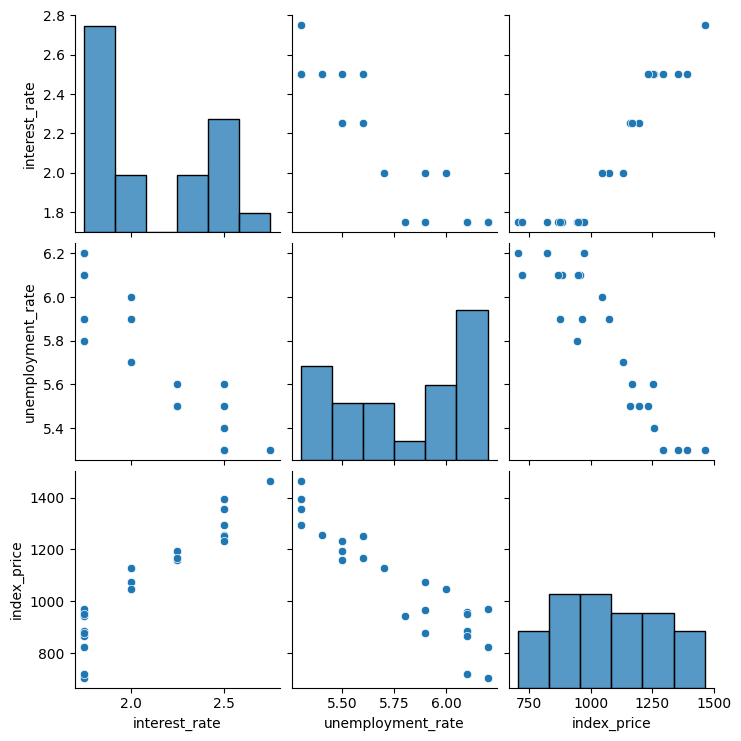

In [13]:
#Visualize using paiplot
sns.pairplot(df)

In [14]:
#Check correlation
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [16]:
# Seperate the Dependent and Independent Features
X = df[['interest_rate', 'unemployment_rate']]
y = df['index_price']

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [23]:
#Train Test split
!pip install scikit-learn
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

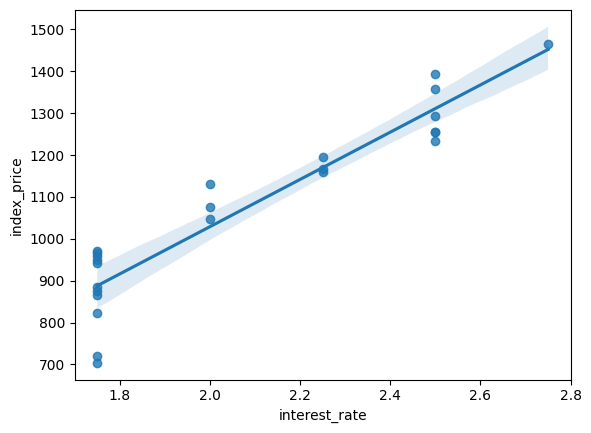

In [ ]:
#Plot using a RegPlot
sns.regplot(x=df['interest_rate'], y=df['index_price'])

In [29]:
# Transformation/Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Applying the Model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#Using Cross Validation, in here the Training data will be split into cv times, ie, here cv is 3, so traindata/3, now each part will be used to find its negative mean squared error, then we can find its average(mean)
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring='neg_mean_squared_error',cv=3)
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [36]:
# Finding the average 
float(np.mean(validation_score))

-5914.828180162396

In [37]:
# Prediction using the test data
y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [38]:
#Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mae)
print(mse)
print(rmse)

59.9357815232356
5793.7628877125835
76.11677139574815


In [39]:
#R2 score
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

0.8278978091457141


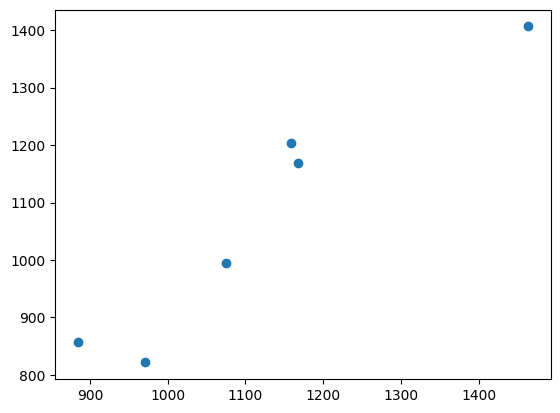

In [40]:
plt.scatter(y_test,y_pred)

In [41]:
# Identifying the residuals to plot and see what distribution it has
residuals = (y_test - y_pred)
print(residuals)

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64


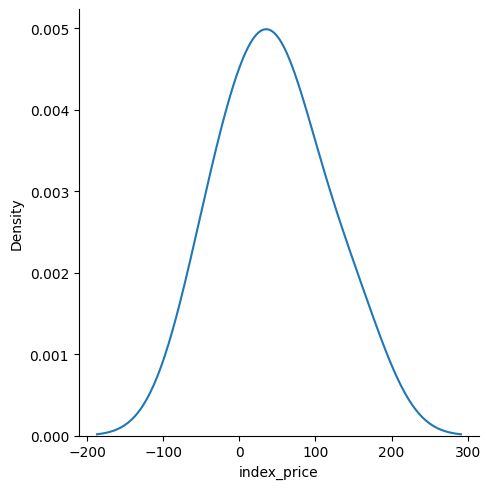

In [ ]:
# Visualizing it using a kde curve, if it is a normal distribution curve, our model is good
sns.displot(residuals,kind='kde')

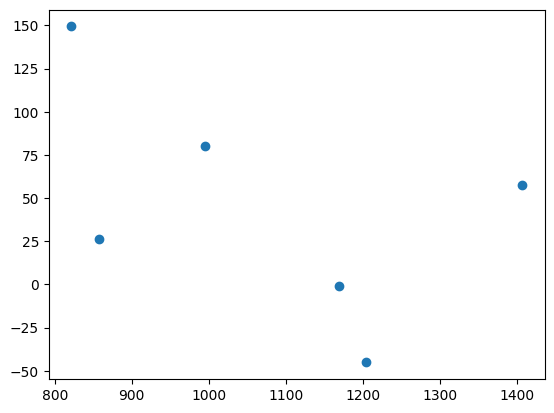

In [43]:
plt.scatter(y_pred,residuals)

In [46]:
#OLS
!pip install statsmodels
import statsmodels.api as sm

In [49]:
model = sm.OLS(y_train,X_train).fit()
model.summary

<bound method RegressionResults.summary of <statsmodels.regression.linear_model.OLSResults object at 0x163a02ad0>>